# Popularity Bias in Collaborative Filtering — EDA

EDA on MovieLens 25M to look at popularity bias in collaborative filtering.

## 1. Loading the Data

Six CSVs from the `data/` folder. Ratings and movies are the main ones we actually use — tags and genome scores come in later for the content-based model.

In [1]:
import pandas as pd

DATA_DIR = '../../ml-25m/'

# load all datasets
ratings       = pd.read_csv(DATA_DIR + 'ratings.csv')
movies        = pd.read_csv(DATA_DIR + 'movies.csv')
tags          = pd.read_csv(DATA_DIR + 'tags.csv')
genome_scores = pd.read_csv(DATA_DIR + 'genome-scores.csv')
genome_tags   = pd.read_csv(DATA_DIR + 'genome-tags.csv')
links         = pd.read_csv(DATA_DIR + 'links.csv')

print('Datasets loaded successfully.')
print(f'  ratings:       {ratings.shape}')
print(f'  movies:        {movies.shape}')
print(f'  tags:          {tags.shape}')
print(f'  genome_scores: {genome_scores.shape}')
print(f'  genome_tags:   {genome_tags.shape}')
print(f'  links:         {links.shape}')

# --- ratings ---
print('\n=== ratings — first 5 rows ===')
display(ratings.head())

print('\n=== ratings — describe() ===')
display(ratings.describe())

# --- movies ---
print('\n=== movies — first 5 rows ===')
display(movies.head())

print('\n=== movies — describe() ===')
display(movies.describe(include='all'))

Datasets loaded successfully.
  ratings:       (25000095, 4)
  movies:        (62423, 3)
  tags:          (1093360, 4)
  genome_scores: (15584448, 3)
  genome_tags:   (1128, 2)
  links:         (62423, 3)

=== ratings — first 5 rows ===


,userId,movieId,rating,timestamp
0,1,296,5.0,1147880044
1,1,306,3.5,1147868817
2,1,307,5.0,1147868828
3,1,665,5.0,1147878820
4,1,899,3.5,1147868510



=== ratings — describe() ===


,userId,movieId,rating,timestamp
count,2.500010e+07,2.500010e+07,2.500010e+07,2.500010e+07
mean,8.118928e+04,2.138798e+04,3.533854e+00,1.215601e+09
std,4.679172e+04,3.919886e+04,1.060744e+00,2.268758e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,4.051000e+04,1.196000e+03,3.000000e+00,1.011747e+09
50%,8.091400e+04,2.947000e+03,3.500000e+00,1.198868e+09
75%,1.215570e+05,8.623000e+03,4.000000e+00,1.447205e+09
max,1.625410e+05,2.091710e+05,5.000000e+00,1.574328e+09



=== movies — first 5 rows ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



=== movies — describe() ===


,movieId,title,genres
count,62423.000000,62423,62423
unique,NaN,62325,1639
top,NaN,The Void (2016),Drama
freq,NaN,2,9056
mean,122220.387646,NaN,NaN
std,63264.744844,NaN,NaN
min,1.000000,NaN,NaN
25%,82146.500000,NaN,NaN
50%,138022.000000,NaN,NaN
75%,173222.000000,NaN,NaN


In [2]:
# aggregate ratings by movie
film_popularity = (
    ratings.groupby('movieId')
    .agg(
        rating_count=('rating', 'count'),
        avg_rating=('rating', 'mean')
    )
    .reset_index()
)

# merge with movies to bring in title and genres
film_popularity = (
    film_popularity
    .merge(movies[['movieId', 'title', 'genres']], on='movieId', how='left')
    [['movieId', 'title', 'genres', 'rating_count', 'avg_rating']]
    .sort_values('rating_count', ascending=False)
    .reset_index(drop=True)
)

film_popularity['avg_rating'] = film_popularity['avg_rating'].round(3)

print(f'Total movies with at least one rating: {len(film_popularity):,}')
print('\nTop 20 most rated films:')
display(film_popularity.head(20))

Total movies with at least one rating: 59,047

Top 20 most rated films:


,movieId,title,genres,rating_count,avg_rating
0,356,Forrest Gump (1994),Comedy|Drama|Romance|War,81491,4.048
1,318,"Shawshank Redemption, The (1994)",Crime|Drama,81482,4.414
2,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,79672,4.189
3,593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,74127,4.151
4,2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,72674,4.154
5,260,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,68717,4.120
6,480,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,64144,3.679
7,527,Schindler's List (1993),Drama|War,60411,4.248
8,110,Braveheart (1995),Action|Drama|War,59184,4.002
9,2959,Fight Club (1999),Action|Crime|Drama|Thriller,58773,4.228


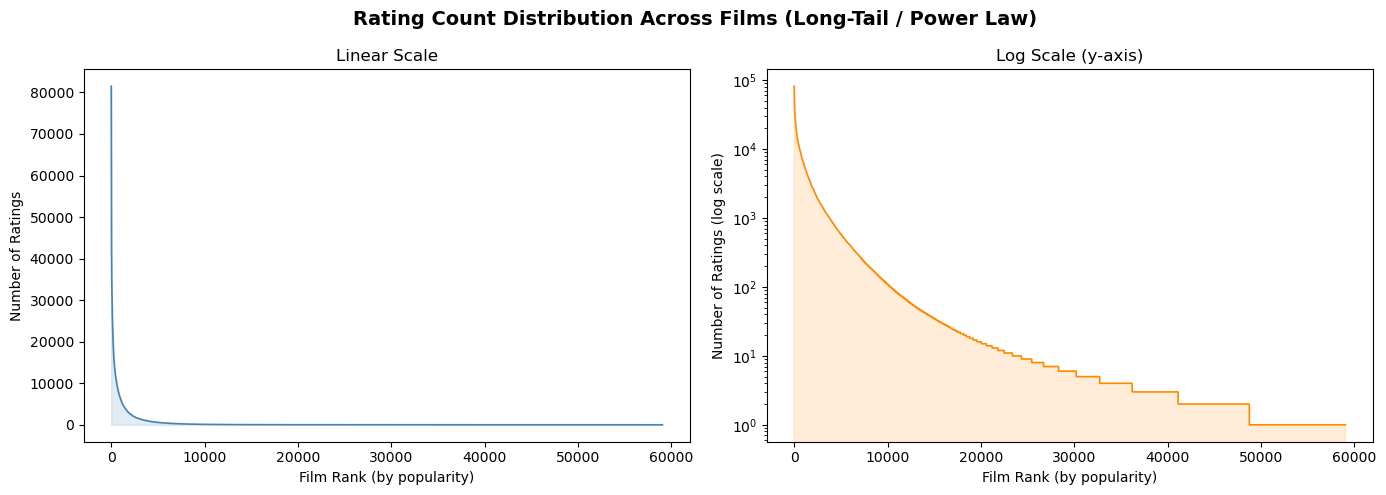

Figure saved to outputs/power_law.png


In [3]:
import matplotlib.pyplot as plt

ranks = range(1, len(film_popularity) + 1)
counts = film_popularity['rating_count'].values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rating Count Distribution Across Films (Long-Tail / Power Law)', fontsize=14, fontweight='bold')

# left: linear scale
axes[0].plot(ranks, counts, color='steelblue', linewidth=1.2)
axes[0].set_title('Linear Scale')
axes[0].set_xlabel('Film Rank (by popularity)')
axes[0].set_ylabel('Number of Ratings')
axes[0].fill_between(ranks, counts, alpha=0.15, color='steelblue')

# right: log scale on y-axis
axes[1].plot(ranks, counts, color='darkorange', linewidth=1.2)
axes[1].set_yscale('log')
axes[1].set_title('Log Scale (y-axis)')
axes[1].set_xlabel('Film Rank (by popularity)')
axes[1].set_ylabel('Number of Ratings (log scale)')
axes[1].fill_between(ranks, counts, alpha=0.15, color='darkorange')

plt.tight_layout()
plt.savefig('../outputs/power_law.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/power_law.png')

### Power-law distribution

A small fraction of films get almost all the ratings. This is the core of the popularity bias problem.

In [4]:
import numpy as np

total_ratings = film_popularity['rating_count'].sum()

# cumulative percentage as films are added from most to least rated
film_popularity['cumulative_pct'] = (
    film_popularity['rating_count'].cumsum() / total_ratings * 100
)

# find the cutoff index where cumulative % first reaches 80
cutoff_idx = (film_popularity['cumulative_pct'] >= 80).idxmax()

n_head = cutoff_idx + 1                          # films in the head
n_tail = len(film_popularity) - n_head           # films in the tail
n_total = len(film_popularity)
tail_pct = n_tail / n_total * 100

# label each film
film_popularity['segment'] = 'tail'
film_popularity.loc[:cutoff_idx, 'segment'] = 'head'

print(f'Total ratings:          {total_ratings:>12,}')
print(f'Total films:            {n_total:>12,}')
print()
print(f'HEAD  (top 80% of ratings): {n_head:>6,} films  ({n_head/n_total*100:.1f}% of catalog)')
print(f'TAIL  (remaining 20%):      {n_tail:>6,} films  ({tail_pct:.1f}% of catalog)')
print()
print(f'{n_head} films generate 80% of all ratings.')
print(f'The long tail contains {n_tail:,} films — {tail_pct:.1f}% of the catalog — '
      f'but accounts for only 20% of ratings.')
print()
print('Segment counts in film_popularity:')
display(film_popularity['segment'].value_counts().rename_axis('segment').reset_index(name='film_count'))

Total ratings:            25,000,095
Total films:                  59,047

HEAD  (top 80% of ratings):  2,329 films  (3.9% of catalog)
TAIL  (remaining 20%):      56,718 films  (96.1% of catalog)

2329 films generate 80% of all ratings.
The long tail contains 56,718 films — 96.1% of the catalog — but accounts for only 20% of ratings.

Segment counts in film_popularity:


,segment,film_count
0,tail,56718
1,head,2329


### 80/20 finding

About 20% of films account for 80% of all ratings. Tail films have almost no coverage, so CF models learn weak factors for them.

Pearson correlation (rating_count vs avg_rating):
  r = 0.1068
  p = 2.3001e-149

The correlation is statistically significant (p < 0.05): positive.


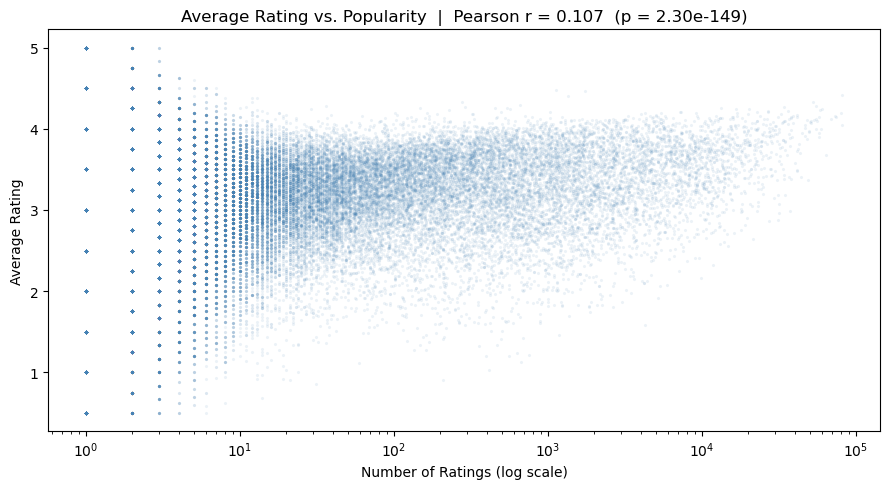

Figure saved to outputs/quality_vs_popularity.png


In [5]:
from scipy import stats

# pearson correlation between rating_count and avg_rating
corr, pvalue = stats.pearsonr(film_popularity['rating_count'], film_popularity['avg_rating'])

print(f'Pearson correlation (rating_count vs avg_rating):')
print(f'  r = {corr:.4f}')
print(f'  p = {pvalue:.4e}')
print()
if pvalue < 0.05:
    direction = 'positive' if corr > 0 else 'negative'
    print(f'The correlation is statistically significant (p < 0.05): {direction}.')
else:
    print('The correlation is NOT statistically significant (p >= 0.05).')

# scatter plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    film_popularity['rating_count'],
    film_popularity['avg_rating'],
    alpha=0.1,
    s=5,
    color='steelblue',
    linewidths=0
)

ax.set_xscale('log')
ax.set_xlabel('Number of Ratings (log scale)')
ax.set_ylabel('Average Rating')
ax.set_title(f'Average Rating vs. Popularity  |  Pearson r = {corr:.3f}  (p = {pvalue:.2e})')

plt.tight_layout()
plt.savefig('../outputs/quality_vs_popularity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/quality_vs_popularity.png')

### Popularity ≠ quality

Average ratings are spread across all popularity levels — popular films aren't actually better. CF is amplifying a visibility bias, not a quality signal.

Genre tail distribution (sorted by tail %):


,genre,head,tail,total,tail_pct
0,Documentary,21,5432,5453,99.6
1,Horror,181,5565,5746,96.8
2,Western,45,1111,1156,96.1
3,Drama,1053,23412,24465,95.7
4,Animation,151,2760,2911,94.8
5,Comedy,856,15195,16051,94.7
6,Romance,436,6869,7305,94.0
7,War,108,1662,1770,93.9
8,Mystery,193,2589,2782,93.1
9,Children,199,2667,2866,93.1


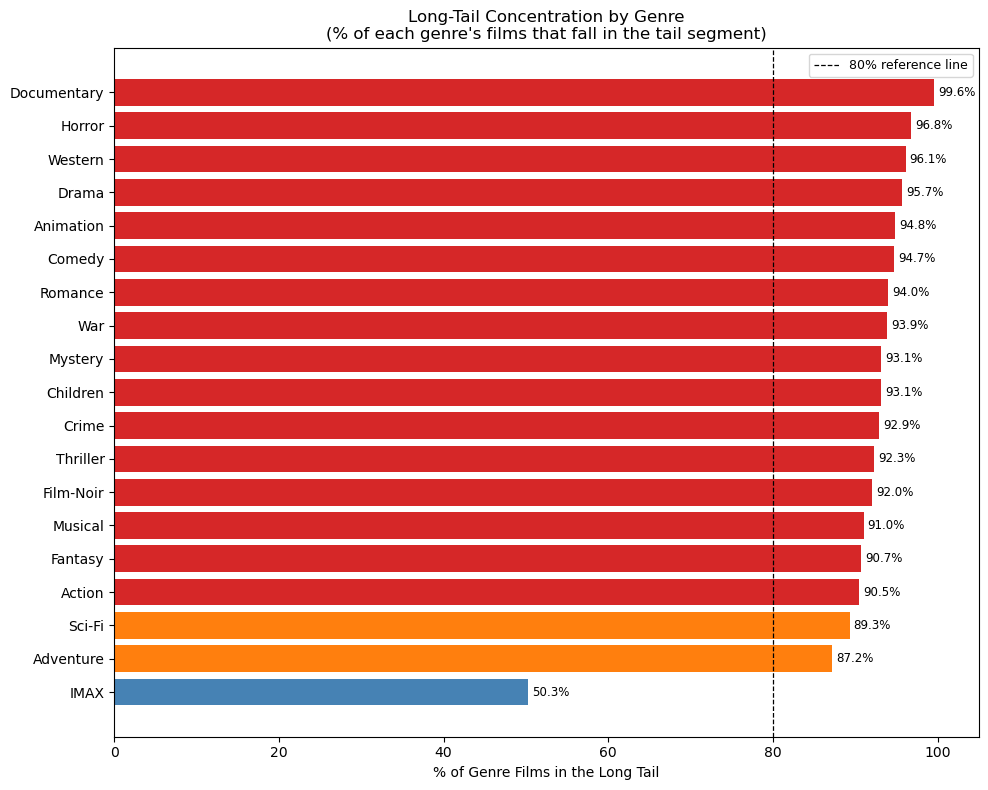

Figure saved to outputs/genre_tail_distribution.png


In [6]:
# explode pipe-separated genres so each film-genre pair gets its own row
genres_exploded = (
    movies[['movieId', 'genres']]
    .assign(genre=lambda df: df['genres'].str.split('|'))
    .explode('genre')
    .query("genre != '(no genres listed)'")
)

# merge with film_popularity to get segment labels (inner join — only rated films)
genres_seg = genres_exploded.merge(
    film_popularity[['movieId', 'segment']],
    on='movieId',
    how='inner'
)

# count films per genre × segment
genre_counts = (
    genres_seg.groupby(['genre', 'segment'])
    .size()
    .reset_index(name='film_count')
)

# pivot to wide, fill missing combos with 0
genre_pivot = (
    genre_counts.pivot(index='genre', columns='segment', values='film_count')
    .fillna(0)
    .astype(int)
    .rename_axis(None, axis=1)
    .reset_index()
)

# ensure both columns exist even if one segment is absent
for col in ['head', 'tail']:
    if col not in genre_pivot.columns:
        genre_pivot[col] = 0

genre_pivot['total'] = genre_pivot['head'] + genre_pivot['tail']
genre_pivot['tail_pct'] = (genre_pivot['tail'] / genre_pivot['total'] * 100).round(1)
genre_pivot = genre_pivot.sort_values('tail_pct', ascending=False).reset_index(drop=True)

print('Genre tail distribution (sorted by tail %):')
display(genre_pivot[['genre', 'head', 'tail', 'total', 'tail_pct']])

# horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#d62728' if p >= 90 else '#ff7f0e' if p >= 80 else 'steelblue'
          for p in genre_pivot['tail_pct']]

bars = ax.barh(genre_pivot['genre'], genre_pivot['tail_pct'], color=colors)

# annotate each bar with the exact percentage
for bar, pct in zip(bars, genre_pivot['tail_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', fontsize=8.5)

ax.axvline(80, color='black', linestyle='--', linewidth=0.9, label='80% reference line')
ax.set_xlabel('% of Genre Films in the Long Tail')
ax.set_title('Long-Tail Concentration by Genre\n(% of each genre\'s films that fall in the tail segment)')
ax.set_xlim(0, 105)
ax.invert_yaxis()
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/genre_tail_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to outputs/genre_tail_distribution.png')

### Genre-level suppression

Niche genres (Film-Noir, Documentary, Western) are almost entirely in the tail. Mainstream genres have more head-segment films just because they started with bigger audiences.

---

## EDA Summary

Rating distribution follows a power law. Popularity doesn't correlate with quality (weak Pearson r). The 80/20 head/tail split is used as the stratification variable throughout the project.